# Homework 04: Matplotlib & NumPy

**Release Date:** Feb 5

**Due Date:** Feb 18 11:59 PM

**Total Points:** 60 pts (+ 5 bonus pts)

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Use appropriate variable names
- Format all outputs professionally with units
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

**Discussion (Task 6):**

A higher activation energy $E_a$ means that a greater fraction of molecular collisions must overcome a larger energy barrier for reaction to occur, making the reaction rate more sensitive to temperature changes. For N₂O₅ decomposition, the fitted $E_a \approx 102.6$ kJ/mol is moderately high — the rate constant increases roughly 45-fold from 273 K to 358 K (just an 85 K rise), confirming strong temperature sensitivity. This is consistent with N₂O₅ being a metastable molecule whose N–O bonds require significant energy to break.

---
## Problem 1: Countercurrent Heat Exchanger — LMTD Analysis

The diagram below shows the **countercurrent** flow arrangement. The hot stream enters from the **left** and exits on the **right**; the cold (utility) stream flows in the **opposite direction** — entering from the **right** and exiting on the **left**.

```
                  COUNTERCURRENT SHELL-AND-TUBE HEAT EXCHANGER
                  ══════════════════════════════════════════════

  HOT stream (shell side)
  ───────────────────────────────────────────────────────────────────►
  T_h,in = 150 °C                                       T_h,out = 50–130 °C
  ṁ_h    = 2.0 kg/s                                     (design sweep)
  c_p,h  = 4.18 kJ/(kg·K)
  ╔══════╦═══════════════════════════════════════════════╦══════╗
  ║      ║░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░║      ║
  ║  IN  ║░░░░░░░░░  TUBE BUNDLE (U = 500 W/m²·K) ░░░░░░░║  OUT ║
  ║      ║░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░║      ║
  ╚══════╩═══════════════════════════════════════════════╩══════╝
  T_c,out = 80 °C                                       T_c,in = 20 °C
  (fixed)                                               (fixed)
  ◄───────────────────────────────────────────────────────────────────
  COLD stream (tube side)


  ΔT at hot inlet end:   ΔT₁ = T_h,in  − T_c,out = 150 − 80  = 70 °C  (fixed)
  ΔT at hot outlet end:  ΔT₂ = T_h,out − T_c,in  = (50–130) − 20      (varies)

                         ΔT₁ − ΔT₂
  LMTD  =  ─────────────────────────────
                   ln( ΔT₁ / ΔT₂ )

  Q  =  ṁ_h · c_p,h · (T_h,in − T_h,out)   [kW]
  A  =  Q / (U · LMTD)                       [m²]
```




In a **countercurrent shell-and-tube heat exchanger**, a hot process stream is cooled by a cold utility stream flowing in the opposite direction. The heat duty and required area are governed by:

$$
Q = \dot{m}_h c_{p,h} (T_{h,\text{in}} - T_{h,\text{out}})
$$

$$
Q = U A \cdot \Delta T_{\text{lm}}
$$

where the **log mean temperature difference (LMTD)** for a countercurrent exchanger is:

$$
\Delta T_{\text{lm}} = \frac{\Delta T_1 - \Delta T_2}{\ln(\Delta T_1 / \Delta T_2)}, \quad \Delta T_1 = T_{h,\text{in}} - T_{c,\text{out}}, \quad \Delta T_2 = T_{h,\text{out}} - T_{c,\text{in}}
$$

**Fixed conditions:**
- Hot stream inlet: $T_{h,\text{in}} = 150$ °C, specific heat $c_{p,h} = 4.18$ kJ/(kg·K), mass flow rate $\dot{m}_h = 2.0$ kg/s
- Cold stream inlet: $T_{c,\text{in}} = 20$ °C
- Overall heat transfer coefficient: $U = 500$ W/(m²·K)

**Design sweep:** vary the **hot stream outlet temperature** $T_{h,\text{out}}$ from 50 °C to 130 °C (use `np.linspace` with 100 points). For each $T_{h,\text{out}}$, assume the cold stream outlet is fixed at $T_{c,\text{out}} = 80$ °C.

**Tasks:**
1. Compute arrays for $Q$ (kW), $\Delta T_{\text{lm}}$ (°C), and required heat transfer area $A$ (m²) across all values of $T_{h,\text{out}}$.  
   *(Hint: be careful with units — convert $U$ to kW/(m²·K) or $Q$ to W consistently.)*
2. Create a **2×1 subplot** (`figsize=(9, 8)`):
   - **Top subplot:** $Q$ (kW) vs $T_{h,\text{out}}$ (°C) — title `'Heat Duty vs Hot Outlet Temperature'`
   - **Bottom subplot:** Required area $A$ (m²) vs $T_{h,\text{out}}$ (°C) — title `'Required Heat Transfer Area vs Hot Outlet Temperature'`
   - Both: label axes, add grid.
3. Using numpy, find and print the **$T_{h,\text{out}}$ that requires the minimum heat transfer area** and report the corresponding $Q$ and $A$ values.
4. Print the **$T_{h,\text{out}}$ range where $\Delta T_{\text{lm}} < 10$ °C** — this is a region of poor driving force.
5. **In a markdown cell below your code**, write 2–3 sentences: *Why does the required area $A$ increase as $T_{h,\text{out}}$ decreases? What practical constraint prevents you from cooling the hot stream all the way to $T_{c,\text{in}}$?*


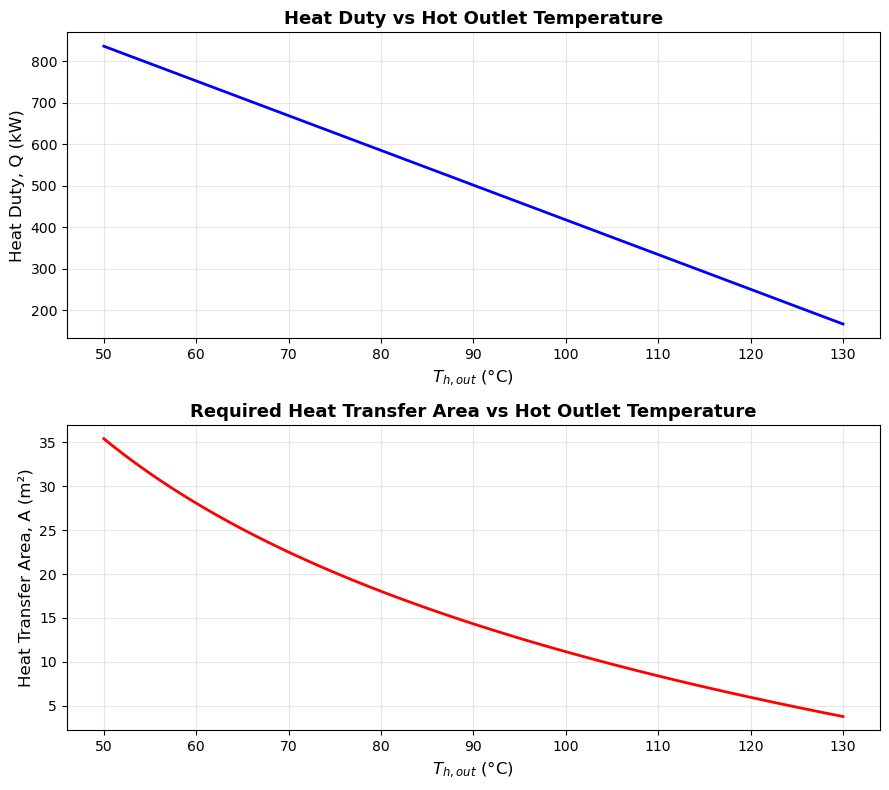

Minimum area condition:
  T_h_out = 130.00 °C
  Q       = 167.20 kW
  A       = 3.779 m²

Low driving-force region (LMTD < 55 °C):
  T_h_out range: 50.00 °C  →  62.12 °C
  LMTD range:   47.21 °C  →  54.89 °C


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed conditions
T_h_in   = 150.0    # °C
T_c_in   =  20.0    # °C
T_c_out  =  80.0    # °C
cp_h     =   4.18   # kJ/(kg·K)
m_dot_h  =   2.0    # kg/s
U        =   0.5    # kW/(m²·K)  [500 W/(m²·K) ÷ 1000]

T_h_out = np.linspace(50, 130, 100)   # °C

# Task 1: Heat duty, LMTD, and required area
Q    = m_dot_h * cp_h * (T_h_in - T_h_out)       # kW

dT1  = T_h_in  - T_c_out                          # = 70 °C  (fixed, hot-in vs cold-out)
dT2  = T_h_out - T_c_in                           # varies  (hot-out vs cold-in)
LMTD = (dT1 - dT2) / np.log(dT1 / dT2)           # °C

A    = Q / (U * LMTD)                             # m²

# Task 2: 2×1 subplots
fig, axes = plt.subplots(2, 1, figsize=(9, 8))

axes[0].plot(T_h_out, Q, 'b-', linewidth=2)
axes[0].set_xlabel('$T_{h,out}$ (°C)', fontsize=12)
axes[0].set_ylabel('Heat Duty, Q (kW)', fontsize=12)
axes[0].set_title('Heat Duty vs Hot Outlet Temperature', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(T_h_out, A, 'r-', linewidth=2)
axes[1].set_xlabel('$T_{h,out}$ (°C)', fontsize=12)
axes[1].set_ylabel('Heat Transfer Area, A (m²)', fontsize=12)
axes[1].set_title('Required Heat Transfer Area vs Hot Outlet Temperature', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3: T_h_out with minimum area
idx_min = np.argmin(A)
print(f"Minimum area condition:")
print(f"  T_h_out = {T_h_out[idx_min]:.2f} °C")
print(f"  Q       = {Q[idx_min]:.2f} kW")
print(f"  A       = {A[idx_min]:.3f} m²")

# Task 4: T_h_out range where LMTD < 55 °C (low driving-force region)
mask = LMTD < 55
if np.any(mask):
    print(f"\nLow driving-force region (LMTD < 55 °C):")
    print(f"  T_h_out range: {T_h_out[mask].min():.2f} °C  →  {T_h_out[mask].max():.2f} °C")
    print(f"  LMTD range:   {LMTD[mask].min():.2f} °C  →  {LMTD[mask].max():.2f} °C")
else:
    print("\nLMTD stays above 55 °C across the entire sweep.")

**Discussion (Task 5):**

As $T_{h,\text{out}}$ decreases, the heat duty $Q$ increases (more heat must be removed), while the LMTD simultaneously decreases because the temperature difference between the two streams shrinks — both effects drive the required area $A = Q / (U \Delta T_{\text{lm}})$ sharply upward. The practical constraint preventing cooling all the way to $T_{c,\text{in}} = 20$ °C is the **temperature pinch**: in a countercurrent exchanger $T_{h,\text{out}}$ must remain above $T_{c,\text{in}}$, otherwise $\Delta T_2 \to 0$, LMTD $\to 0$, and the required area becomes infinite — physically impossible regardless of exchanger size.

---
## Problem 4: NumPy Array Operations — Temperature Data

You are given temperature readings (in °C) from **3 sensors** at **6 time points** (every 10 minutes):

```
data = np.array([
    [22.1, 35.4, 48.2, 59.7, 68.3, 72.5],   # Sensor 1
    [21.8, 34.9, 47.5, 58.1, 67.0, 71.2],   # Sensor 2
    [22.5, 36.0, 49.1, 61.2, 70.4, 74.8],   # Sensor 3
])
```

**Tasks:**
1. Print the **shape**, **number of dimensions**, and **total number of elements** of `data`.
2. Convert all temperatures from **°C to Kelvin** (add 273.15) and store as `data_K`.
3. Using `axis` arguments, compute and print:
   - The **mean temperature at each time point** (average across sensors)
   - The **mean temperature for each sensor** (average across time)
4. Find and print the **maximum temperature recorded** and which sensor it came from (use `np.argmax`).
5. Extract and print the **last two time points** for all sensors using slicing.

In [3]:
import numpy as np

data = np.array([
    [22.1, 35.4, 48.2, 59.7, 68.3, 72.5],   # Sensor 1
    [21.8, 34.9, 47.5, 58.1, 67.0, 71.2],   # Sensor 2
    [22.5, 36.0, 49.1, 61.2, 70.4, 74.8],   # Sensor 3
])

# Task 1: Shape, dimensions, size
print("Shape:       ", data.shape)
print("Dimensions:  ", data.ndim)
print("Total elements:", data.size)

# Task 2: Convert to Kelvin
data_K = data + 273.15
print("\nData in Kelvin:\n", data_K)

# Task 3: Mean along axes
mean_per_time   = np.mean(data, axis=0)   # average across sensors (collapse rows)
mean_per_sensor = np.mean(data, axis=1)   # average across time (collapse columns)

time_points = [0, 10, 20, 30, 40, 50]
print("\nMean temperature at each time point (°C):")
for t, m in zip(time_points, mean_per_time):
    print(f"  t = {t:2d} min: {m:.2f} °C")

print("\nMean temperature per sensor (°C):")
for i, m in enumerate(mean_per_sensor, start=1):
    print(f"  Sensor {i}: {m:.2f} °C")

# Task 4: Maximum temperature and which sensor
max_temp = np.max(data)
sensor_idx = np.argmax(np.max(data, axis=1))   # sensor with the overall max
print(f"\nMaximum temperature recorded: {max_temp} °C")
print(f"  → from Sensor {sensor_idx + 1}")

# Task 5: Last two time points for all sensors (columns -2 and -1)
last_two = data[:, -2:]
print("\nLast two time points for all sensors (°C):")
print(last_two)

Shape:        (3, 6)
Dimensions:   2
Total elements: 18

Data in Kelvin:
 [[295.25 308.55 321.35 332.85 341.45 345.65]
 [294.95 308.05 320.65 331.25 340.15 344.35]
 [295.65 309.15 322.25 334.35 343.55 347.95]]

Mean temperature at each time point (°C):
  t =  0 min: 22.13 °C
  t = 10 min: 35.43 °C
  t = 20 min: 48.27 °C
  t = 30 min: 59.67 °C
  t = 40 min: 68.57 °C
  t = 50 min: 72.83 °C

Mean temperature per sensor (°C):
  Sensor 1: 51.03 °C
  Sensor 2: 50.08 °C
  Sensor 3: 52.33 °C

Maximum temperature recorded: 74.8 °C
  → from Sensor 3

Last two time points for all sensors (°C):
[[68.3 72.5]
 [67.  71.2]
 [70.4 74.8]]


---
## Problem 5: Scatter Plot with Error Bars — Experimental Data

A student measured the **solubility of KNO₃** (g per 100 mL water) at different temperatures. Each measurement was repeated 3 times; below are the mean values and standard deviations:

| Temperature (°C) | Solubility mean (g/100 mL) | Std dev (g/100 mL) |
|-----------------|---------------------------|--------------------|
| 0  | 13.3 | 0.4 |
| 20 | 31.6 | 0.7 |
| 40 | 63.9 | 1.1 |
| 60 | 110.0 | 1.8 |
| 80 | 169.0 | 2.5 |
| 100 | 246.0 | 3.2 |

**Tasks:**
1. Use `plt.errorbar()` to plot solubility vs. temperature with error bars representing the standard deviation.
   - Use `fmt='o-'`, `capsize=5`, `color='steelblue'`.
2. Add axis labels (`'Temperature (°C)'`, `'Solubility (g/100 mL)'`), title, and grid.
3. Using numpy, compute and print the **percent relative standard deviation** (`std/mean * 100`) for each temperature. Use `np.array` for the mean and std data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

temperature = np.array([0, 20, 40, 60, 80, 100])       # °C
solubility  = np.array([13.3, 31.6, 63.9, 110.0, 169.0, 246.0])  # g/100 mL
std_dev     = np.array([0.4, 0.7, 1.1, 1.8, 2.5, 3.2])            # g/100 mL

# Task 1 & 2: Error bar plot
plt.figure(figsize=(8, 5))
plt.errorbar(temperature, solubility, yerr=std_dev,
             fmt='o-', capsize=5, color='steelblue',
             ecolor='black', elinewidth=1.5,
             linewidth=2, markersize=7, label='Solubility ± SD')
plt.xlabel('Temperature (°C)', fontsize=13)
plt.ylabel('Solubility (g/100 mL)', fontsize=13)
plt.title('Solubility of KNO₃ vs Temperature', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 3: Percent relative standard deviation
percent_rsd = std_dev / solubility * 100
print("Percent Relative Standard Deviation (%RSD):")
for T, rsd in zip(temperature, percent_rsd):
    print(f"  T = {T:3d} °C:  %RSD = {rsd:.2f}%")

---
## Problem 6: Combined NumPy + Matplotlib — Reactor Temperature Profile

A batch reactor heats from ambient temperature (298 K) to a setpoint of 450 K following:

$$
T(t) = T_{\infty} - (T_{\infty} - T_0)\, e^{-\alpha t}
$$

with $T_0 = 298$ K, $T_\infty = 450$ K, $\alpha = 0.15$ min⁻¹, over $t = 0$ to $30$ min.

The reaction rate constant follows the Arrhenius equation:

$$
k(T) = A \, e^{-E_a / (RT)}
$$

with $A = 1.0 \times 10^8$ min⁻¹, $E_a = 50{,}000$ J/mol, $R = 8.314$ J/(mol·K).

**Tasks:**
1. Use `np.linspace(0, 30, 300)` for time.
2. Compute `T(t)` and `k(T(t))` using numpy (no loops).
3. Create a **2×1 subplot figure** (`figsize=(8, 8)`):
   - **Top subplot:** Temperature (K) vs. Time (min) — label axes, add title `'Reactor Temperature Profile'`, grid.
   - **Bottom subplot:** Rate constant k (min⁻¹) vs. Time (min) — label axes, add title `'Arrhenius Rate Constant vs. Time'`, grid.
4. Add `plt.tight_layout()`.
5. Print the **maximum rate constant** and the **time at which it occurs** (use `np.argmax`).

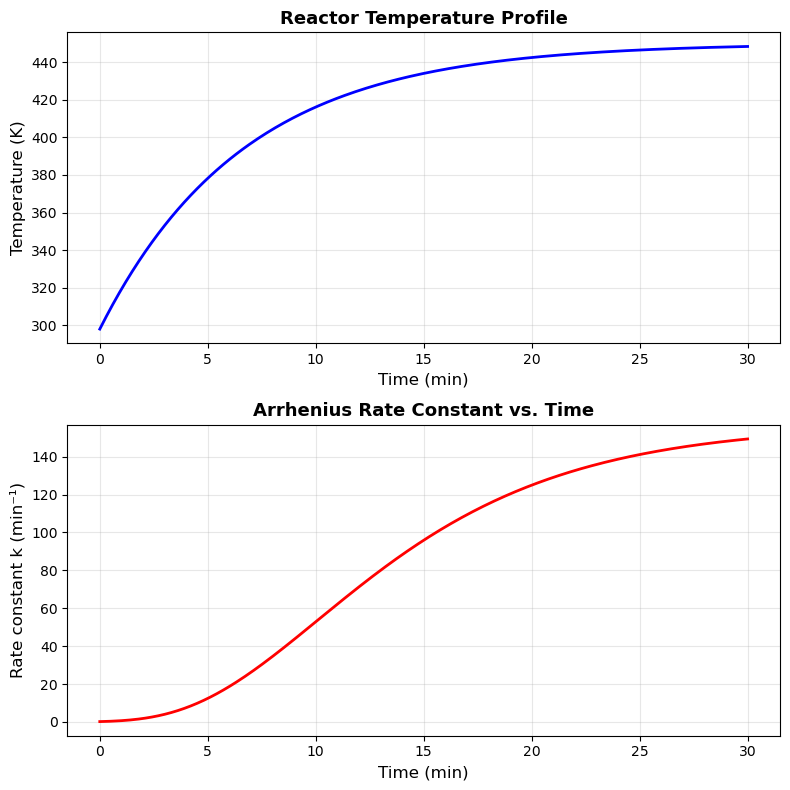

Maximum rate constant: k = 1.4931e+02 min⁻¹
Occurs at t = 30.00 min


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T0    = 298.0        # K
T_inf = 450.0        # K
alpha = 0.15         # min^-1
A     = 1.0e8        # min^-1 (pre-exponential factor)
Ea    = 50000.0      # J/mol
R     = 8.314        # J/(mol·K)

# Task 1 & 2: Compute T(t) and k(T) using numpy (no loops)
t = np.linspace(0, 30, 300)                      # min
T = T_inf - (T_inf - T0) * np.exp(-alpha * t)    # K
k = A * np.exp(-Ea / (R * T))                    # min^-1

# Task 3: 2x1 subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Top: Temperature profile
axes[0].plot(t, T, 'b-', linewidth=2)
axes[0].set_xlabel('Time (min)', fontsize=12)
axes[0].set_ylabel('Temperature (K)', fontsize=12)
axes[0].set_title('Reactor Temperature Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Bottom: Arrhenius rate constant
axes[1].plot(t, k, 'r-', linewidth=2)
axes[1].set_xlabel('Time (min)', fontsize=12)
axes[1].set_ylabel('Rate constant k (min⁻¹)', fontsize=12)
axes[1].set_title('Arrhenius Rate Constant vs. Time', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 5: Max rate constant and time at which it occurs
k_max = np.max(k)
t_max = t[np.argmax(k)]
print(f"Maximum rate constant: k = {k_max:.4e} min⁻¹")
print(f"Occurs at t = {t_max:.2f} min")